# F_tau vs. FDC: real time series vs. BrainLM attention -- new `timepoint_patching_size=1` model

Adapted from `../../validation/ftau_fdc_asymmetry_check.ipynb` (`old_13M`,
`timepoint_patching_size=20`) for the model trained in `../train.py`
(`timepoint_patching_size=1`, `WINDOW=32`; see `../README.md`).

**Terminology** (unchanged from the original):

- **F_tau**: the raw, *unaveraged* `[num_regions, num_regions]` submatrix of the full
  `[seq_len, seq_len]` last-layer attention matrix for one specific (source time patch,
  target time patch) pair. `postprocess.compute_ftau` (averaging that block over every
  valid source patch) is a *different*, aggregate quantity.
- **FDC** ("delay connectivity"): the aggregate, lag-`tau` matrix -- from real BOLD time
  series (`lagged_fc`, variance-normalized tau-lagged cross-covariance; `tau=0` is plain
  Pearson FC) or from attention (`compute_ftau`).
- Since `timepoint_patching_size=1`, **1 time patch = 1 TR** -- the smallest lag the
  model's tokenization can express is now a single TR, instead of `old_13M`'s 20 TR. This
  is the *ideal* case for this analysis: lag structure can be tested at native TR
  resolution instead of being quantized into 20-TR bins.

**What changed vs. the original notebook:**

- **Checkpoint**: local directory instead of the HuggingFace Hub.
- **`WINDOW_SIZE`**: 200 -> 32 TRs (must match training; also keeps `seq_len` tractable
  at `timepoint_patching_size=1` -- see `fc_attention_correlation.ipynb`'s note for the
  full reasoning).
- **`LAG_PATCHES_LIST`**: `[1,2,3,4]` (20/40/60/80 TR under `old_13M`) -> `[1,2,3,4,10,20]`
  TR -- dense coverage of the short lags `timepoint_patching_size=1` newly makes testable,
  plus a couple of longer lags for context. `WINDOW_SIZE=32` caps the largest usable lag
  at 31 TR, so this list stays within range.
- **Part 3 (FCD) dropped.** FCD needs a *separate FC snapshot per time patch*, each
  computed from only that patch's own TRs. At `timepoint_patching_size=1` a "patch" is a
  single TR, and Pearson correlation over one timepoint is undefined (no variance to
  correlate) -- unlike F_tau/FDC above, which only need the *shift* between two signals
  to be 1 TR, not the sample size (they're computed over the whole window). There's no
  larger snapshot size available without changing `WINDOW_SIZE` itself, which is already
  fixed to match training -- see `fc_attention_correlation.ipynb` for the corresponding
  whole-window comparison instead. Parts 1, 2, 4, 5 below are all still valid, unchanged
  in their math (only relabeled Part 3/4 -> Part 3/4 in this notebook, keeping the
  original's internal numbering for cross-reference where noted).


In [1]:
import os
import sys

MAX_CPU_THREADS = 4
os.environ["OMP_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(MAX_CPU_THREADS)

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_num_threads(MAX_CPU_THREADS)

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("../.."))
from run_model_1tr import load_brainlm_model, load_spatial_coordinates
from postprocess import compute_ftau

get_ipython().run_line_magic("matplotlib", "inline")

INPUT_H5 = "../../data/input/fmri_timeseries_subset_100.h5"
COORDS = "../../data/input/toolkit/atlases/A424_Coordinates.dat"
CHECKPOINT_DIR = "checkpoint"

WINDOW_SIZE = 32  # TRs; must match training (num_timepoints_per_voxel) -- see ../README.md
TAU_PATCHES = 1   # 1 TR, since timepoint_patching_size=1 (was 20 TR under old_13M)

N_SUBJECTS = 25
RANDOM_SEED = 0

FIGURES_DIR = "figures"
OUTPUTS_DIR = "outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model, config = load_brainlm_model(CHECKPOINT_DIR)
model.to(device)
spatial_coords_base = load_spatial_coordinates(COORDS)

num_regions = config.num_brain_voxels
num_patches = WINDOW_SIZE // config.timepoint_patching_size
seq_len = num_regions * num_patches
tau_trs = TAU_PATCHES * config.timepoint_patching_size
identity_noise = torch.arange(seq_len, dtype=torch.float32) / seq_len

print(f"num_regions={num_regions}, num_patches={num_patches}, seq_len={seq_len}, "
      f"tau={TAU_PATCHES} patch(es) = {tau_trs} TR")


Device: cpu


/share/data1/mossf/miniconda3/envs/brainlm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading weights file checkpoint/pytorch_model.bin


All model checkpoint weights were used when initializing BrainLMForPretraining.



All the weights of BrainLMForPretraining were initialized from the model checkpoint at checkpoint.
If your task is similar to the task the model of the checkpoint was trained on, you can already use BrainLMForPretraining for predictions without further training.


num_regions=424, num_patches=32, seq_len=13568, tau=1 patch(es) = 1 TR


In [3]:
with h5py.File(INPUT_H5, "r") as f:
    all_subject_ids = [s.decode("utf-8") for s in f["subject_ids"][:]]
    n_available = f["parcel_ts"].shape[0]

rng = np.random.default_rng(RANDOM_SEED)
subject_indices = np.linspace(0, N_SUBJECTS - 1, N_SUBJECTS).astype(int)
print("Subjects:", [all_subject_ids[i] for i in subject_indices])


Subjects: ['Sub_0000', 'Sub_0001', 'Sub_0002', 'Sub_0004', 'Sub_0005', 'Sub_0006', 'Sub_0007', 'Sub_0008', 'Sub_0009', 'Sub_0010', 'Sub_0011', 'Sub_0012', 'Sub_0013', 'Sub_0014', 'Sub_0015', 'Sub_0016', 'Sub_0017', 'Sub_0018', 'Sub_0019', 'Sub_0020', 'Sub_0021', 'Sub_0022', 'Sub_0023', 'Sub_0024', 'Sub_0025']


In [2]:
def robust_scale_regions(window_raw):
    """Per-region median/IQR scaling, same recipe as run_model_1tr.py's
    preprocess_subject_data, applied to a single [window_size, num_regions] window."""
    scaled = window_raw.T.copy()
    for r in range(scaled.shape[0]):
        v = scaled[r, :]
        median = np.median(v)
        q75, q25 = np.percentile(v, [75, 25])
        iqr = q75 - q25
        if iqr == 0:
            iqr = 1e-6
        scaled[r, :] = (v - median) / iqr
    return scaled


def compute_subject_attention(sub_idx):
    """Single WINDOW_SIZE-TR window (TRs [0, WINDOW_SIZE)) last-layer attention
    (heads averaged, CLS dropped) for one subject.
    Returns (subject_id, raw_ts [T, num_regions], attn_no_cls [seq_len, seq_len])."""
    with h5py.File(INPUT_H5, "r") as f:
        sub_id = f["subject_ids"][sub_idx].decode("utf-8")
        raw_ts = f["parcel_ts"][sub_idx, :, :]

    window_raw = raw_ts[:WINDOW_SIZE, :]
    scaled = robust_scale_regions(window_raw)
    fmri_window = torch.tensor(scaled[None, ...], dtype=torch.float32).to(device)

    spatial_coords = spatial_coords_base.to(device)
    noise = identity_noise.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model.vit(
            signal_vectors=fmri_window,
            xyz_vectors=spatial_coords,
            noise=noise,
            output_attentions=True,
        )

    ids_restore = outputs.ids_restore.cpu().numpy()
    if not np.array_equal(ids_restore, np.broadcast_to(np.arange(seq_len), ids_restore.shape)):
        raise RuntimeError(f"{sub_id}: token order was shuffled (ids_restore != identity); refusing to reshape.")

    avg_attention = outputs.attentions[-1].mean(dim=1)[0]
    attn_no_cls = avg_attention[1:, 1:].cpu().numpy().astype("float32")
    return sub_id, raw_ts, attn_no_cls


In [5]:
subjects = []
for idx in subject_indices:
    sub_id, raw_ts, attn_no_cls = compute_subject_attention(idx)
    subjects.append({"subject_id": sub_id, "raw_ts": raw_ts, "attn_no_cls": attn_no_cls})
    print(f"{sub_id}: raw_ts={raw_ts.shape}, attn_no_cls={attn_no_cls.shape}")


Sub_0000: raw_ts=(1200, 424), attn_no_cls=(13568, 13568)


Sub_0001: raw_ts=(1200, 424), attn_no_cls=(13568, 13568)


Sub_0002: raw_ts=(1200, 424), attn_no_cls=(13568, 13568)


Sub_0004: raw_ts=(1200, 424), attn_no_cls=(13568, 13568)


Sub_0005: raw_ts=(1200, 424), attn_no_cls=(13568, 13568)


...

Sub_0021: raw_ts=(1200, 424), attn_no_cls=(13568, 13568)


Sub_0022: raw_ts=(1200, 424), attn_no_cls=(13568, 13568)


Sub_0023: raw_ts=(1200, 424), attn_no_cls=(13568, 13568)


Sub_0024: raw_ts=(1200, 424), attn_no_cls=(13568, 13568)


Sub_0025: raw_ts=(1200, 424), attn_no_cls=(13568, 13568)


## Part 1 -- F_tau: the raw submatrix, element [0, 1] of the full attention matrix

The full `[seq_len, seq_len]` last-layer attention decomposes into a
`(num_patches x num_patches)` grid of `[num_regions, num_regions]` blocks. F_tau is one
of those blocks, picked out directly -- no averaging. With `T_SRC=0` and
`T_TGT=TAU_PATCHES=1` this is "element [0, 1]" of that grid (a 1-TR lag).


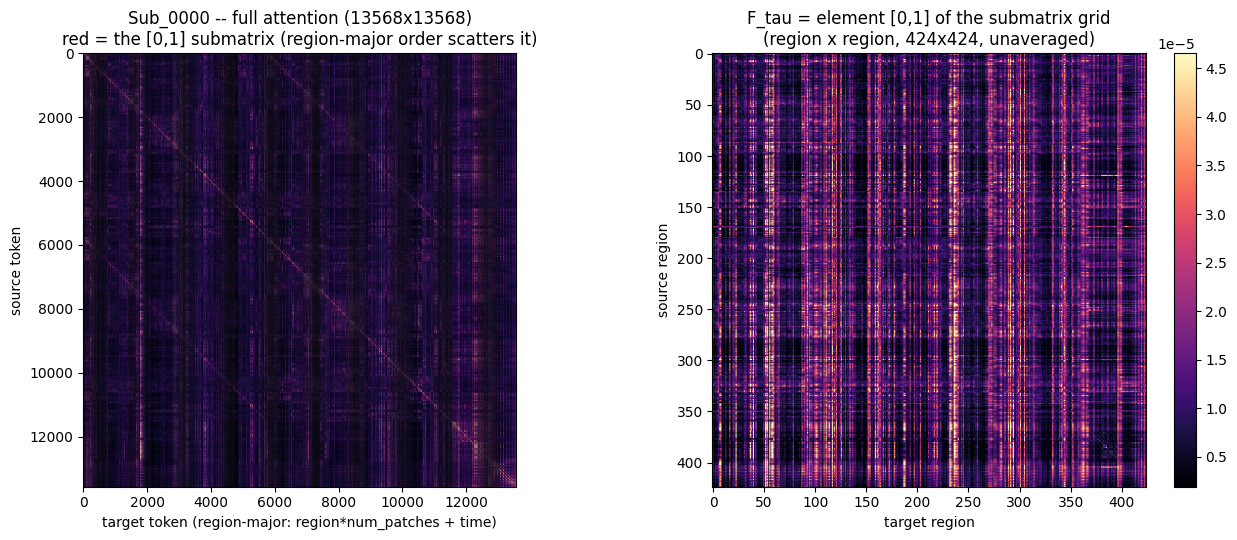

In [6]:
def raw_ftau_block(attn_no_cls, num_regions, num_patches, t_src, t_tgt):
    """The single, UNAVERAGED [num_regions, num_regions] submatrix of the full
    [seq_len, seq_len] attention matrix for one specific (source time patch, target
    time patch) pair. attn_no_cls must use BrainLM's native region-major token order."""
    attn_4d = attn_no_cls.reshape(num_regions, num_patches, num_regions, num_patches)
    return attn_4d[:, t_src, :, t_tgt]

sub = subjects[0]
T_SRC, T_TGT = 0, 1  # "element [0, 1]" of the submatrix grid, for TAU_PATCHES=1

ftau_block = raw_ftau_block(sub["attn_no_cls"], num_regions, num_patches, T_SRC, T_TGT)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

full = sub["attn_no_cls"]
v_lo, v_hi = np.percentile(full, 1), np.percentile(full, 99)
axes[0].imshow(full, cmap="magma", vmin=v_lo, vmax=v_hi)

rows = np.arange(T_SRC, seq_len, num_patches)
cols = np.arange(T_TGT, seq_len, num_patches)
row_grid, col_grid = np.meshgrid(rows, cols, indexing="ij")
axes[0].scatter(col_grid.ravel(), row_grid.ravel(), s=0.1, marker="s", color="red", alpha=0.25, rasterized=True)
axes[0].set_title(f"{sub['subject_id']} -- full attention ({seq_len}x{seq_len})\n"
                   f"red = the [{T_SRC},{T_TGT}] submatrix (region-major order scatters it)")
axes[0].set_xlabel("target token (region-major: region*num_patches + time)")
axes[0].set_ylabel("source token")

v_lo2, v_hi2 = np.percentile(ftau_block, 1), np.percentile(ftau_block, 99)
im1 = axes[1].imshow(ftau_block, cmap="magma", vmin=v_lo2, vmax=v_hi2)
axes[1].set_title(f"F_tau = element [{T_SRC},{T_TGT}] of the submatrix grid\n(region x region, 424x424, unaveraged)")
axes[1].set_xlabel("target region")
axes[1].set_ylabel("source region")
fig.colorbar(im1, ax=axes[1], fraction=0.046)

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_raw_submatrix.png"), dpi=130, bbox_inches="tight")
plt.show()


### Selected lags from region 0, both directions

`num_patches=32`, so time-patch indices run `0..31` -- unlike `old_13M` (`num_patches=10`,
all 9 lags shown), showing all 31 available lags here would be an unreadably wide figure.
Instead we show the same lags analyzed in Part 3/4 below (`LAG_PATCHES_LIST`), forward
`[0,t]` and backward `[t,0]`, sharing one color scale.


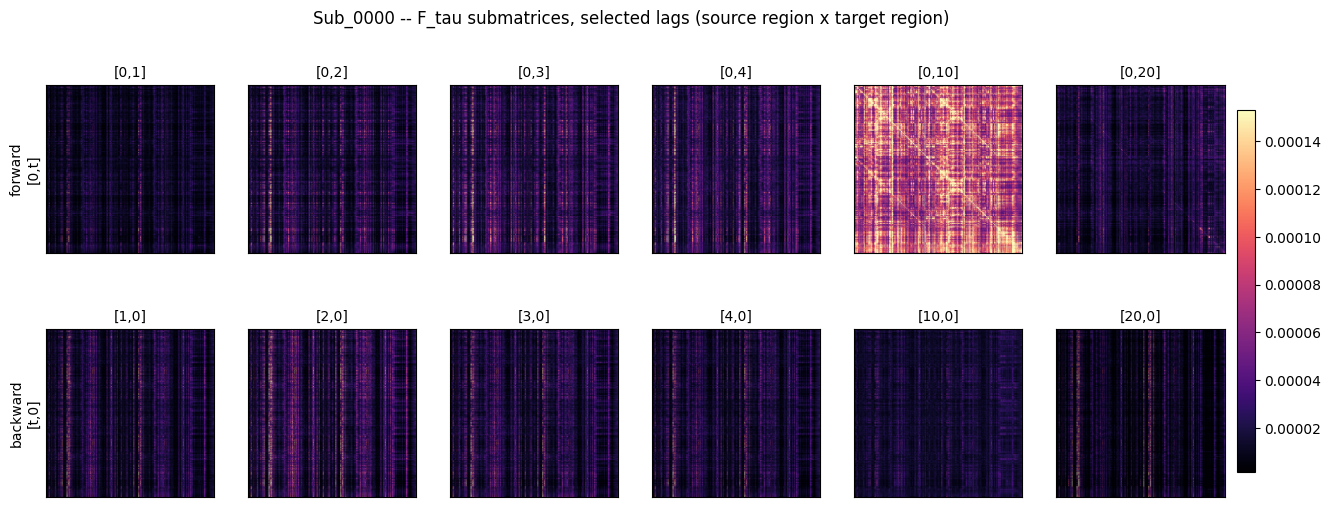

In [7]:
LAG_PATCHES_LIST = [1, 2, 3, 4, 10, 20]  # TR, since timepoint_patching_size=1

taus = [t for t in LAG_PATCHES_LIST if t < num_patches]
forward_blocks = [raw_ftau_block(sub["attn_no_cls"], num_regions, num_patches, 0, t) for t in taus]
backward_blocks = [raw_ftau_block(sub["attn_no_cls"], num_regions, num_patches, t, 0) for t in taus]

all_vals = np.concatenate([b.ravel() for b in forward_blocks + backward_blocks])
v_lo, v_hi = np.percentile(all_vals, 1), np.percentile(all_vals, 99)

fig, axes = plt.subplots(2, len(taus), figsize=(2.6 * len(taus), 5.8))
for col, (t, block) in enumerate(zip(taus, forward_blocks)):
    axes[0, col].imshow(block, cmap="magma", vmin=v_lo, vmax=v_hi)
    axes[0, col].set_title(f"[0,{t}]", fontsize=10)
    axes[0, col].set_xticks([])
    axes[0, col].set_yticks([])
for col, (t, block) in enumerate(zip(taus, backward_blocks)):
    im = axes[1, col].imshow(block, cmap="magma", vmin=v_lo, vmax=v_hi)
    axes[1, col].set_title(f"[{t},0]", fontsize=10)
    axes[1, col].set_xticks([])
    axes[1, col].set_yticks([])

axes[0, 0].set_ylabel("forward\n[0,t]")
axes[1, 0].set_ylabel("backward\n[t,0]")
fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01)
fig.suptitle(f"{sub['subject_id']} -- F_tau submatrices, selected lags (source region x target region)", y=0.98)
fig.savefig(os.path.join(FIGURES_DIR, "ftau_selected_lags_from_region0.png"), dpi=130, bbox_inches="tight")
plt.show()


## Part 2 -- F_tau: real ts vs. attention, matrix correlation and asymmetry

`F_tau_real[i, j] = corr(region i at t, region j at t + tau)` over the real BOLD time
series, `tau = 1` patch (`tau_trs` = 1 TR now, vs. 20 TR under `old_13M`). `F_tau_attn` is
Part 1's raw, unaveraged `[0, 1]` submatrix. Both sides describe the same `TRs
0:WINDOW_SIZE` stretch of recording that the model actually saw.


In [8]:
def lagged_fc(ts, tau):
    """Variance-normalized, tau-lagged cross-covariance of a [num_regions, num_timepoints]
    time series: out[i, j] = corr(region i at t, region j at t + tau), averaged over valid t.
    tau=0 reduces exactly to np.corrcoef(ts)."""
    ts_c = ts - ts.mean(axis=1, keepdims=True)
    T = ts.shape[1]
    std = np.sqrt(np.mean(ts_c ** 2, axis=1))
    std[std <= 0] = 1e-12
    if tau == 0:
        cov = ts_c @ ts_c.T / T
    else:
        cov = ts_c[:, :-tau] @ ts_c[:, tau:].T / (T - tau)
    return cov / np.outer(std, std)

def clean_ts(raw_ts):
    """[T, num_regions] -> [num_regions, T] with trailing all-NaN timepoints dropped."""
    ts = raw_ts.T
    invalid = np.isnan(ts).any(axis=0)
    return ts[:, ~invalid] if invalid.any() else ts

def window0_ts(raw_ts):
    """Real time series restricted to the model's window (TRs 0:WINDOW_SIZE) --
    matches attn_no_cls above."""
    return clean_ts(raw_ts[:WINDOW_SIZE])

iu = np.triu_indices(num_regions, k=1)

asym_results = []
for s in subjects:
    ts = window0_ts(s["raw_ts"])
    ftau_real = lagged_fc(ts, tau=tau_trs)
    ftau_attn = raw_ftau_block(s["attn_no_cls"], num_regions, num_patches, T_SRC, T_TGT)

    r_ftau = np.corrcoef(ftau_real.ravel(), ftau_attn.ravel())[0, 1]

    asym_real = (ftau_real - ftau_real.T) / 2.0
    asym_attn = (ftau_attn - ftau_attn.T) / 2.0
    r_asymmetry = np.corrcoef(asym_real[iu], asym_attn[iu])[0, 1]

    asym_results.append({
        "subject_id": s["subject_id"],
        "ftau_real": ftau_real, "ftau_attn": ftau_attn,
        "asym_real": asym_real, "asym_attn": asym_attn,
        "score_real": float(np.mean(np.abs(asym_real))),
        "score_attn": float(np.mean(np.abs(asym_attn))),
        "r_ftau": r_ftau,
        "r_asymmetry": r_asymmetry,
    })
    print(f"{s['subject_id']}: r(F_tau_real, F_tau_attn) = {r_ftau:.4f}, "
          f"asymmetry score real={asym_results[-1]['score_real']:.2e}, attn={asym_results[-1]['score_attn']:.2e}, "
          f"r(asym_real, asym_attn) = {r_asymmetry:.4f}")


Sub_0000: r(F_tau_real, F_tau_attn) = -0.0357, asymmetry score real=7.77e-02, attn=4.74e-06, r(asym_real, asym_attn) = -0.0373


Sub_0001: r(F_tau_real, F_tau_attn) = -0.0537, asymmetry score real=8.83e-02, attn=4.86e-06, r(asym_real, asym_attn) = -0.0146
Sub_0002: r(F_tau_real, F_tau_attn) = 0.0102, asymmetry score real=8.70e-02, attn=4.57e-06, r(asym_real, asym_attn) = 0.0363


Sub_0004: r(F_tau_real, F_tau_attn) = -0.0167, asymmetry score real=8.50e-02, attn=4.57e-06, r(asym_real, asym_attn) = -0.0044
Sub_0005: r(F_tau_real, F_tau_attn) = 0.0323, asymmetry score real=7.74e-02, attn=3.44e-06, r(asym_real, asym_attn) = -0.0313


Sub_0006: r(F_tau_real, F_tau_attn) = -0.0840, asymmetry score real=8.25e-02, attn=4.67e-06, r(asym_real, asym_attn) = -0.0514


Sub_0007: r(F_tau_real, F_tau_attn) = -0.0490, asymmetry score real=8.91e-02, attn=4.78e-06, r(asym_real, asym_attn) = -0.0080


Sub_0008: r(F_tau_real, F_tau_attn) = -0.0355, asymmetry score real=9.45e-02, attn=4.71e-06, r(asym_real, asym_attn) = -0.0542
Sub_0009: r(F_tau_real, F_tau_attn) = -0.0418, asymmetry score real=7.91e-02, attn=4.82e-06, r(asym_real, asym_attn) = -0.0363
Sub_0010: r(F_tau_real, F_tau_attn) = -0.0103, asymmetry score real=8.06e-02, attn=4.54e-06, r(asym_real, asym_attn) = 0.0222
Sub_0011: r(F_tau_real, F_tau_attn) = -0.0397, asymmetry score real=7.00e-02, attn=3.34e-06, r(asym_real, asym_attn) = -0.0038
Sub_0012: r(F_tau_real, F_tau_attn) = -0.0614, asymmetry score real=9.02e-02, attn=4.62e-06, r(asym_real, asym_attn) = -0.0466
Sub_0013: r(F_tau_real, F_tau_attn) = -0.0199, asymmetry score real=8.13e-02, attn=4.65e-06, r(asym_real, asym_attn) = 0.0048
Sub_0014: r(F_tau_real, F_tau_attn) = -0.0463, asymmetry score real=8.68e-02, attn=4.72e-06, r(asym_real, asym_attn) = 0.0311
Sub_0015: r(F_tau_real, F_tau_attn) = 0.0206, asymmetry score real=8.08e-02, attn=3.79e-06, r(asym_real, asym_attn

Sub_0016: r(F_tau_real, F_tau_attn) = 0.0120, asymmetry score real=9.28e-02, attn=4.73e-06, r(asym_real, asym_attn) = -0.0228
Sub_0017: r(F_tau_real, F_tau_attn) = 0.0148, asymmetry score real=7.82e-02, attn=3.87e-06, r(asym_real, asym_attn) = 0.0303
Sub_0018: r(F_tau_real, F_tau_attn) = -0.0503, asymmetry score real=7.92e-02, attn=4.72e-06, r(asym_real, asym_attn) = -0.0279


Sub_0019: r(F_tau_real, F_tau_attn) = -0.0396, asymmetry score real=8.39e-02, attn=4.92e-06, r(asym_real, asym_attn) = 0.0006
Sub_0020: r(F_tau_real, F_tau_attn) = 0.0013, asymmetry score real=8.54e-02, attn=4.04e-06, r(asym_real, asym_attn) = -0.0293


Sub_0021: r(F_tau_real, F_tau_attn) = -0.0142, asymmetry score real=8.40e-02, attn=4.68e-06, r(asym_real, asym_attn) = -0.0259


Sub_0022: r(F_tau_real, F_tau_attn) = -0.0454, asymmetry score real=7.93e-02, attn=4.52e-06, r(asym_real, asym_attn) = -0.0069
Sub_0023: r(F_tau_real, F_tau_attn) = -0.0573, asymmetry score real=8.58e-02, attn=4.67e-06, r(asym_real, asym_attn) = -0.0507
Sub_0024: r(F_tau_real, F_tau_attn) = -0.0568, asymmetry score real=9.18e-02, attn=4.19e-06, r(asym_real, asym_attn) = -0.0344
Sub_0025: r(F_tau_real, F_tau_attn) = -0.0310, asymmetry score real=9.55e-02, attn=5.06e-06, r(asym_real, asym_attn) = -0.0016


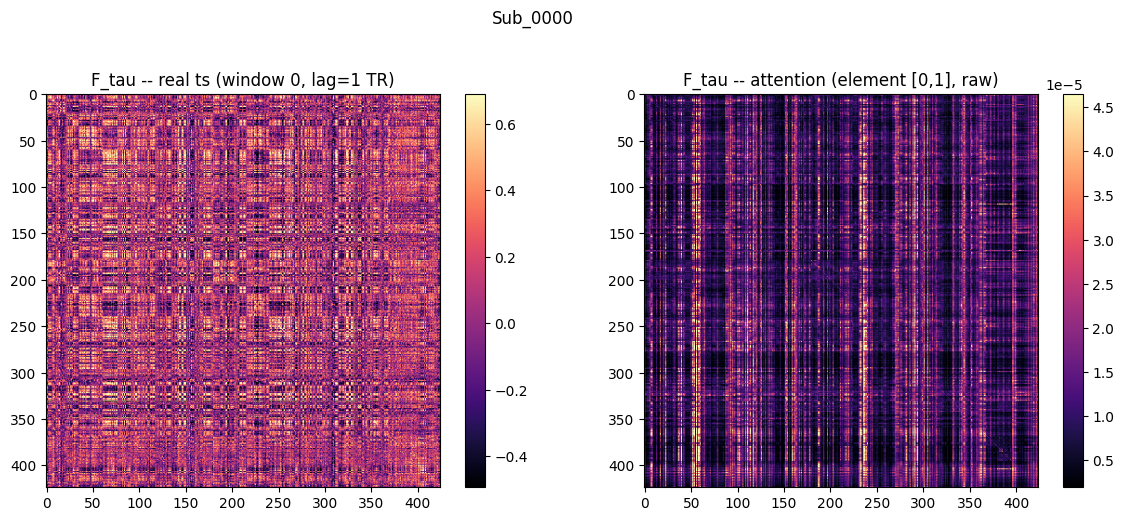

In [9]:
sub_res = asym_results[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, mat, title in zip(axes[:2], [sub_res["ftau_real"], sub_res["ftau_attn"]],
                           ["F_tau -- real ts (window 0, lag=1 TR)", "F_tau -- attention (element [0,1], raw)"]):
    v_lo, v_hi = np.percentile(mat, 1), np.percentile(mat, 99)
    im = ax.imshow(mat, cmap="magma", vmin=v_lo, vmax=v_hi)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle(sub_res["subject_id"], y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_real_vs_attention_matrices.png"), dpi=130, bbox_inches="tight")
plt.show()


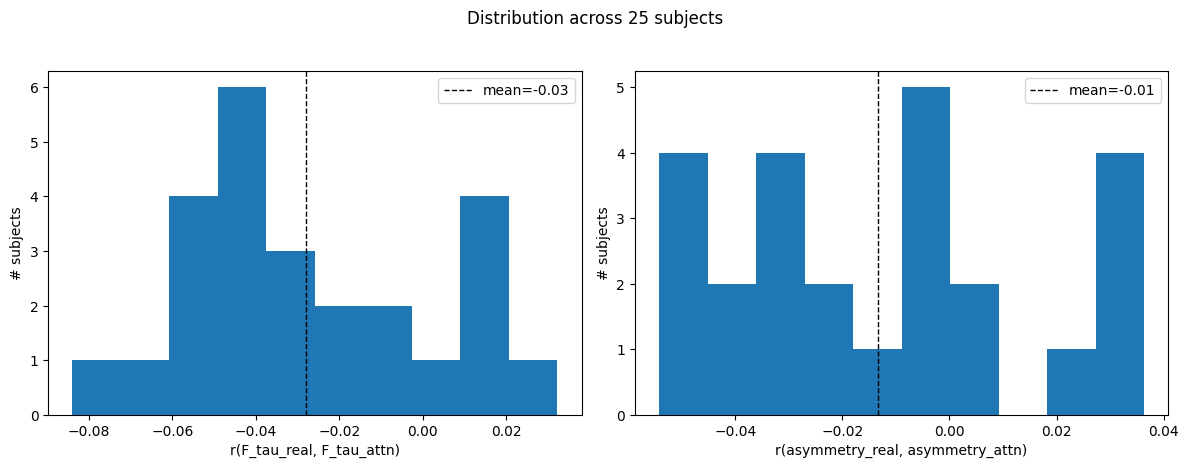

In [10]:
r_ftau_vals = np.array([r["r_ftau"] for r in asym_results])
r_asym_vals = np.array([r["r_asymmetry"] for r in asym_results])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, vals, label in zip(axes, [r_ftau_vals, r_asym_vals],
                           ["r(F_tau_real, F_tau_attn)", "r(asymmetry_real, asymmetry_attn)"]):
    ax.hist(vals, bins=min(10, len(vals)), color="tab:blue")
    ax.axvline(np.nanmean(vals), color="black", linestyle="--", linewidth=1, label=f"mean={np.nanmean(vals):.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("# subjects")
    ax.legend()

fig.suptitle(f"Distribution across {len(asym_results)} subjects", y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_correlation_distributions.png"), dpi=130, bbox_inches="tight")
plt.show()


### Real F_tau (window 0) across increasing tau

Sanity check before comparing against attention at a single lag: how does the real-ts
shifted FC `F_tau(t, t+tau)` change as `tau` grows? Five increasing lags up to the actual
comparison lag (`tau_trs` = 1 TR) -- with `tau_trs=1` this collapses to essentially one
meaningful step (`tau=1`) plus `tau=0` (plain FC), unlike `old_13M`'s 20-TR comparison lag
which had more room for intermediate steps.


In [3]:
ts0 = window0_ts(subjects[0]["raw_ts"])
taus_trs = sorted({max(0, int(round(tau_trs * f))) for f in [0, 0.25, 0.5, 0.75, 1.0]})
shifted_fcs = [lagged_fc(ts0, tau=t) for t in taus_trs]

all_vals = np.concatenate([m.ravel() for m in shifted_fcs])
v_lo, v_hi = np.percentile(all_vals, 1), np.percentile(all_vals, 99)

fig, axes = plt.subplots(1, len(taus_trs), figsize=(3.2 * len(taus_trs), 4.2))
if len(taus_trs) == 1:
    axes = [axes]
for ax, t, mat in zip(axes, taus_trs, shifted_fcs):
    im = ax.imshow(mat, cmap="magma", vmin=v_lo, vmax=v_hi)
    ax.set_title(f"tau={t} TR" + (" (used above)" if t == tau_trs else ""), fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.01)
fig.suptitle(f"{subjects[0]['subject_id']} -- real ts shifted FC F_tau(t, t+tau), window 0, increasing tau", y=1.03)
fig.savefig(os.path.join(FIGURES_DIR, "ftau_real_increasing_tau.png"), dpi=130, bbox_inches="tight")
plt.show()


NameError: name 'window0_ts' is not defined

## Part 3 (FCD) omitted for this model

The original `old_13M` notebook had a "Part 3 -- FCD" here: functional connectivity
*dynamics*, correlating `num_patches` per-time-patch FC snapshots (each computed from
only that patch's own TRs) into a time x time matrix, for both real ts and attention's
diagonal blocks.

At `timepoint_patching_size=1`, a "patch" is a single TR, and `np.corrcoef` over one
timepoint is undefined (zero degrees of freedom for a variance estimate) -- there is no
way to compute a per-patch FC snapshot the way the original notebook does. Since
`WINDOW_SIZE=32` is already fixed to match training, there's no larger snapshot size
available to substitute without changing what window the model is actually being run on.
See `fc_attention_correlation.ipynb`'s "single fixed-window" section for the
whole-window analog of this comparison (FC computed on the full 32-TR window against
time-averaged attention over that same window) -- that one *is* well-defined and kept.


## Part 4 -- Aggregate F_tau vs. FDC across multiple lags (averaged over time)

Hypothesis: averaging every off-diagonal attention block at a fixed lag `k` TR --
`compute_ftau(attn_no_cls, ..., tau=k)`, i.e. `mean_t attn_4d[:, t, :, t+k]` -- is the
attention analog of the real lagged FC computed on the full window-0 series at the
matching lag, `lagged_fc(ts, tau=k)` (since `patch_size=1`, `k` patches = `k` TR
directly, no multiplication needed). Averaging over `t` removes the temporal dimension
entirely, so this can only test whether the lag-`k` *structure* matches in aggregate --
not whether it holds patch-by-patch (that's Part 5).

Lags tested: `1, 2, 3, 4, 10, 20` TR -- dense coverage of the short lags
`timepoint_patching_size=1` newly makes testable (`old_13M` could only express lags in
20-TR steps), plus two longer lags for context. All are within `WINDOW_SIZE=32`'s valid
range (`< num_patches`).


In [12]:
patch_size = config.timepoint_patching_size  # = 1

agg_results = []
for lag in LAG_PATCHES_LIST:
    for s in subjects:
        ts = window0_ts(s["raw_ts"])
        ftau_attn_agg = compute_ftau(s["attn_no_cls"], num_regions, num_patches, tau=lag)
        ftau_real_agg = lagged_fc(ts, tau=lag * patch_size)
        r = np.corrcoef(ftau_attn_agg.ravel(), ftau_real_agg.ravel())[0, 1]
        agg_results.append({
            "subject_id": s["subject_id"], "lag_patches": lag, "lag_tr": lag * patch_size, "r_agg": r,
        })

for lag in LAG_PATCHES_LIST:
    vals = np.array([r["r_agg"] for r in agg_results if r["lag_patches"] == lag])
    print(f"lag={lag} TR: r(FDC_real, F_tau_attn_avg) "
          f"mean={np.nanmean(vals):.4f}, median={np.nanmedian(vals):.4f}, std={np.nanstd(vals):.4f}")


lag=1 TR: r(FDC_real, F_tau_attn_avg) mean=0.0433, median=0.0444, std=0.0402
lag=2 TR: r(FDC_real, F_tau_attn_avg) mean=0.0098, median=0.0087, std=0.0378
lag=3 TR: r(FDC_real, F_tau_attn_avg) mean=-0.0088, median=-0.0115, std=0.0351
lag=4 TR: r(FDC_real, F_tau_attn_avg) mean=-0.0287, median=-0.0295, std=0.0372
lag=10 TR: r(FDC_real, F_tau_attn_avg) mean=-0.0350, median=-0.0467, std=0.0442
lag=20 TR: r(FDC_real, F_tau_attn_avg) mean=-0.0254, median=-0.0220, std=0.0666


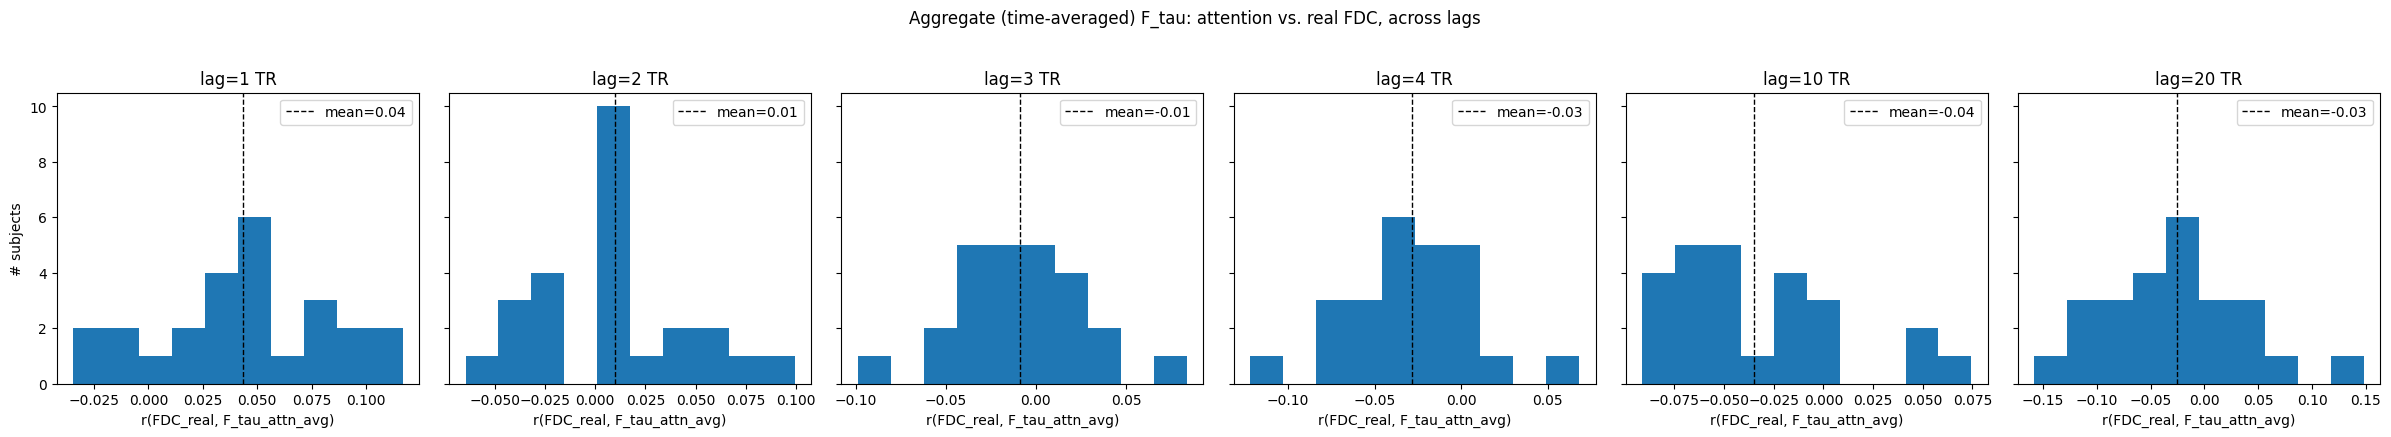

In [13]:
fig, axes = plt.subplots(1, len(LAG_PATCHES_LIST), figsize=(4 * len(LAG_PATCHES_LIST), 4.2), sharey=True)
for ax, lag in zip(axes, LAG_PATCHES_LIST):
    vals = np.array([r["r_agg"] for r in agg_results if r["lag_patches"] == lag])
    ax.hist(vals, bins=min(10, len(vals)), color="tab:blue")
    ax.axvline(np.nanmean(vals), color="black", linestyle="--", linewidth=1, label=f"mean={np.nanmean(vals):.2f}")
    ax.set_title(f"lag={lag} TR")
    ax.set_xlabel("r(FDC_real, F_tau_attn_avg)")
    ax.legend()
axes[0].set_ylabel("# subjects")

fig.suptitle("Aggregate (time-averaged) F_tau: attention vs. real FDC, across lags", y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_aggregate_vs_fdc_by_lag.png"), dpi=130, bbox_inches="tight")
plt.show()


## Part 5 -- Per-patch F_tau: does the lag-k structure hold block by block?

Part 4 averaged over every valid source patch `t`, which can hide patch-by-patch
disagreement even when the aggregate correlation looks good. Here each `(t, t+k)` block
is kept separate instead: for lag `k` (TR, since `patch_size=1`), `attn_4d[:, t, :, t+k]`
(`t = 0 .. num_patches-k-1`) is compared against the matching real time-series term.

Note this is *not* subject to the same degeneracy as the dropped FCD section: each block
here uses **whole-window** variance for normalization (`lagged_fc_by_patch` centers/scales
against the full `WINDOW_SIZE`-TR series, matching `lagged_fc`), and only the covariance
*numerator* is a single-TR-pair term -- it's one term of a well-defined sum, not an
independent per-slice correlation estimate. `mean(lagged_fc_by_patch(...), axis=0) ==
lagged_fc(ts, tau=k)` (verified numerically to ~1e-15 in the original notebook).


In [14]:
def lagged_fc_by_patch(ts, patch_size, num_patches, lag_patches):
    """Same global (whole-window) centering/normalization as lagged_fc, but returns the
    individual per-source-patch [num_regions, num_regions] blocks separately instead of
    averaging them. mean(blocks, axis=0) == lagged_fc(ts, tau=lag_patches*patch_size)."""
    ts_c = ts - ts.mean(axis=1, keepdims=True)
    std = np.sqrt(np.mean(ts_c ** 2, axis=1))
    std[std <= 0] = 1e-12
    norm = np.outer(std, std)

    blocks = []
    for t in range(num_patches - lag_patches):
        src = ts_c[:, t * patch_size:(t + 1) * patch_size]
        tgt = ts_c[:, (t + lag_patches) * patch_size:(t + lag_patches + 1) * patch_size]
        cov = src @ tgt.T / patch_size
        blocks.append(cov / norm)
    return blocks


per_block_results = []
for lag in LAG_PATCHES_LIST:
    for s in subjects:
        ts = window0_ts(s["raw_ts"])
        real_blocks = lagged_fc_by_patch(ts, patch_size, num_patches, lag)
        for t, real_block in enumerate(real_blocks):
            attn_block = raw_ftau_block(s["attn_no_cls"], num_regions, num_patches, t, t + lag)
            r = np.corrcoef(real_block.ravel(), attn_block.ravel())[0, 1]
            per_block_results.append({
                "subject_id": s["subject_id"], "lag_patches": lag, "t_src": t, "t_tgt": t + lag, "r_block": r,
            })

print(f"{len(per_block_results)} (subject, lag, t) comparisons total")
for lag in LAG_PATCHES_LIST:
    vals = np.array([r["r_block"] for r in per_block_results if r["lag_patches"] == lag])
    print(f"lag={lag} TR: r(F_tau_real_block, F_tau_attn_block) "
          f"mean={np.nanmean(vals):.4f}, median={np.nanmedian(vals):.4f}, std={np.nanstd(vals):.4f}")


3800 (subject, lag, t) comparisons total
lag=1 TR: r(F_tau_real_block, F_tau_attn_block) mean=-0.1030, median=-0.0949, std=0.0864
lag=2 TR: r(F_tau_real_block, F_tau_attn_block) mean=-0.1082, median=-0.1013, std=0.0949
lag=3 TR: r(F_tau_real_block, F_tau_attn_block) mean=-0.1112, median=-0.1043, std=0.1013
lag=4 TR: r(F_tau_real_block, F_tau_attn_block) mean=-0.1182, median=-0.1078, std=0.1042
lag=10 TR: r(F_tau_real_block, F_tau_attn_block) mean=-0.0841, median=-0.0735, std=0.1026
lag=20 TR: r(F_tau_real_block, F_tau_attn_block) mean=-0.0462, median=-0.0368, std=0.0767


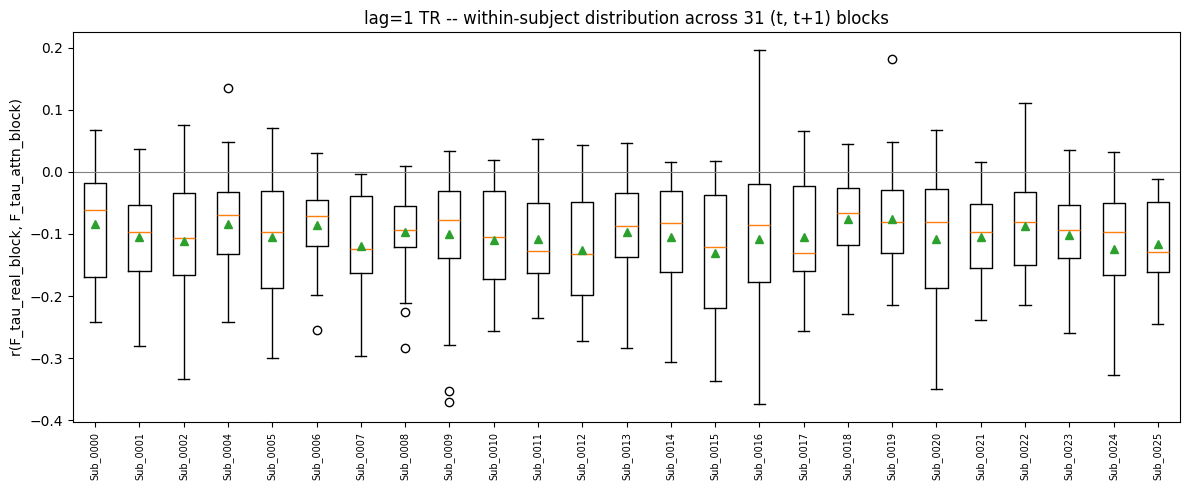

In [15]:
sub_ids = [s["subject_id"] for s in subjects]
lag1_by_subject = [
    [r["r_block"] for r in per_block_results if r["lag_patches"] == 1 and r["subject_id"] == sid]
    for sid in sub_ids
]

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.boxplot(lag1_by_subject, showmeans=True)
ax.set_xticks(range(1, len(sub_ids) + 1))
ax.set_xticklabels(sub_ids, rotation=90, fontsize=7)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_ylabel("r(F_tau_real_block, F_tau_attn_block)")
ax.set_title(f"lag=1 TR -- within-subject distribution across {num_patches - 1} (t, t+1) blocks")

fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_per_block_within_subject_lag1.png"), dpi=130, bbox_inches="tight")
plt.show()


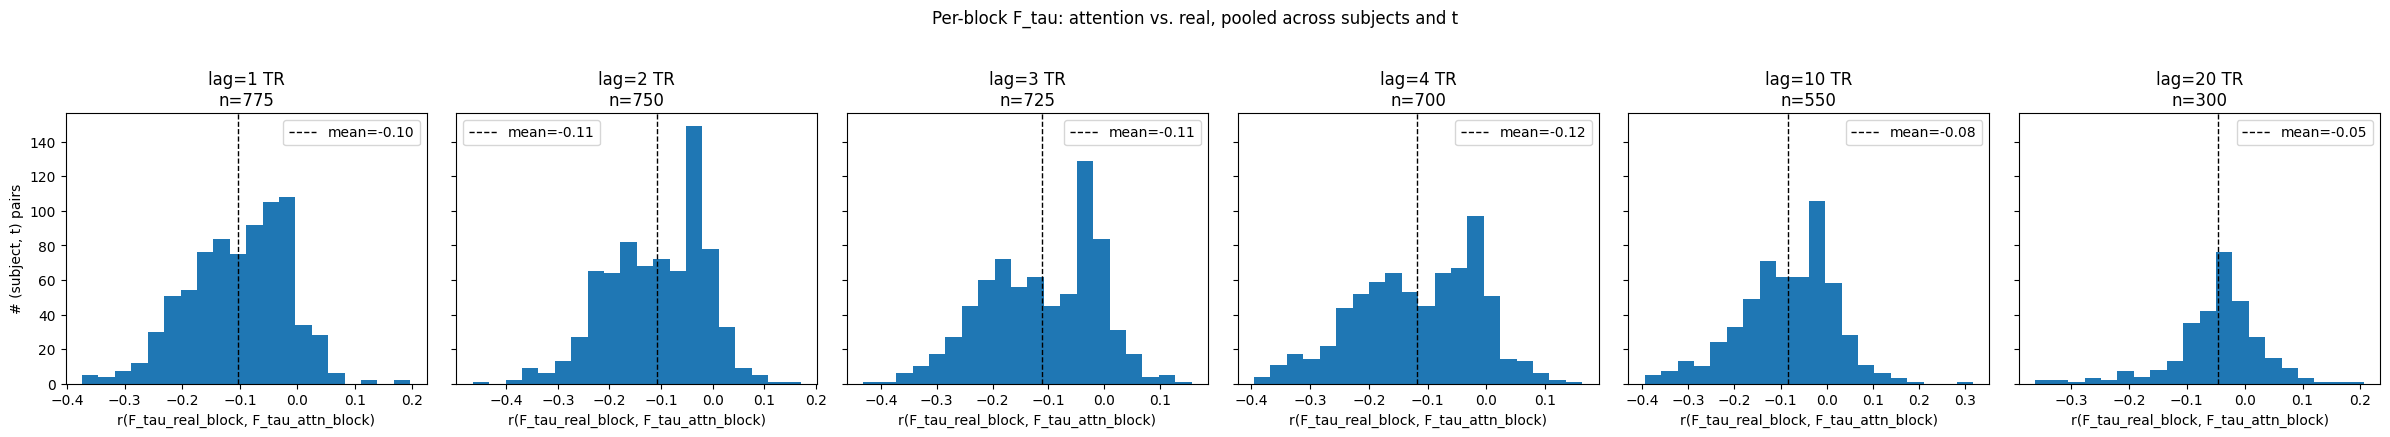

In [16]:
fig, axes = plt.subplots(1, len(LAG_PATCHES_LIST), figsize=(4 * len(LAG_PATCHES_LIST), 4.2), sharey=True)
for ax, lag in zip(axes, LAG_PATCHES_LIST):
    vals = np.array([r["r_block"] for r in per_block_results if r["lag_patches"] == lag])
    ax.hist(vals, bins=20, color="tab:blue")
    ax.axvline(np.nanmean(vals), color="black", linestyle="--", linewidth=1, label=f"mean={np.nanmean(vals):.2f}")
    ax.set_title(f"lag={lag} TR\nn={len(vals)}")
    ax.set_xlabel("r(F_tau_real_block, F_tau_attn_block)")
    ax.legend()
axes[0].set_ylabel("# (subject, t) pairs")

fig.suptitle("Per-block F_tau: attention vs. real, pooled across subjects and t", y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, "ftau_per_block_pooled_by_lag.png"), dpi=130, bbox_inches="tight")
plt.show()
